In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# data manipulation
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt

# statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#import statsmodels.tsa.api as smt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# r'C:\Users\Admin\Desktop\StockTSMC.csv'
# 'C:\\Users\\Admin\\Desktop\\StockTSMC.csv'
# 'C:/Users/Admin/Desktop/StockTSMC.csv'
file = r"C:\Users\YangYUCheng\Desktop\機器學習實驗結果\程式碼\資料前處理\New_Stock_TSMC_最新股價.csv"

In [4]:
# data = pd.read_csv(file)  pandas 會自動產生一個 數字 index
"""
index | Date       | ClosingPrice | Volume
------------------------------------------
0     | 2023-01-01 | 500          | 10000
1     | 2023-01-02 | 510          | 12000
2     | 2023-01-03 | 505          | 15000
"""
# data = pd.read_csv(file, index_col="Date")
# 則 pandas 會把 Date 欄位移到 index，也就是把 Date 欄位當作索引，之後查找資料時，就可以直接使用 Date 來查找資料
"""
Date        | ClosingPrice | Volume
------------------------------------
2023-01-01  | 500          | 10000
2023-01-02  | 510          | 12000
2023-01-03  | 505          | 15000
"""

'\nDate        | ClosingPrice | Volume\n------------------------------------\n2023-01-01  | 500          | 10000\n2023-01-02  | 510          | 12000\n2023-01-03  | 505          | 15000\n'

In [5]:
data = pd.read_csv(file)
data = data.set_index("Date")
df = pd.DataFrame(data)

#print(df.columns)
#df
#print(type(df.index))   # pandas.core.indexes.base.Index

In [6]:
# 把 DataFrame 的 index（目前是字串日期）轉換成 datetime 型態
# pd.to_datetime()，把日期字串 → 轉成 datetime 型態
df.index = pd.to_datetime(df.index)

# df.sort_index()，把 index 的日期排序，從最早的日期到最新的日期
df = df.sort_index()
# print(type(df.index))   # pandas.core.indexes.datetimes.DatetimeIndex
# df

Date
2022-01-03     631.0
2022-01-04     656.0
2022-01-05     650.0
2022-01-06     644.0
2022-01-07     634.0
               ...  
2025-12-24    1495.0
2025-12-26    1510.0
2025-12-29    1530.0
2025-12-30    1520.0
2025-12-31    1550.0
Name: ClosingPrice, Length: 969, dtype: float64
float64


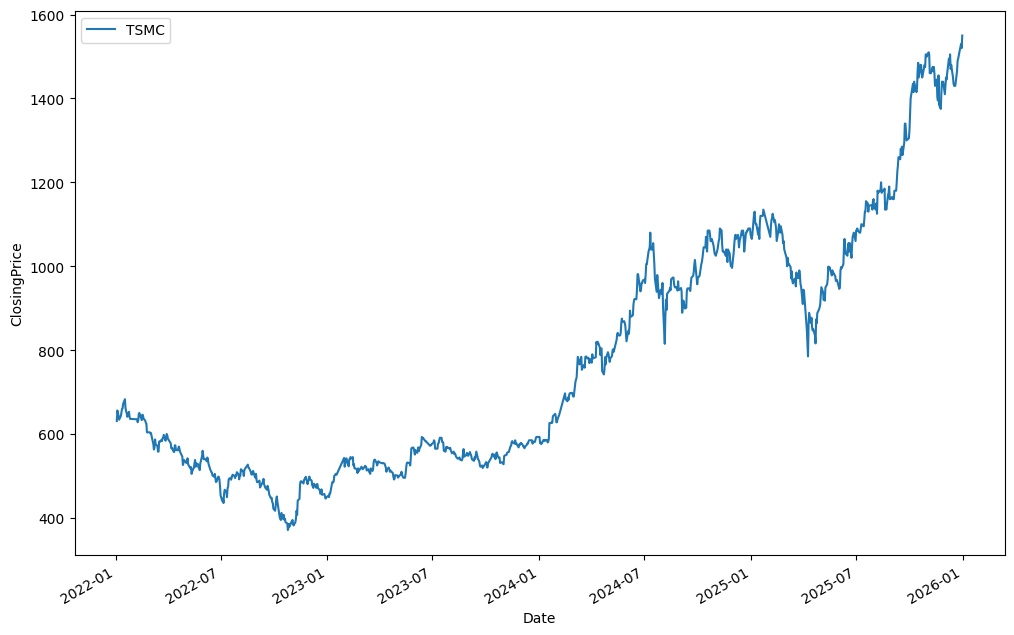

In [7]:
# df = pd.DataFrame(data)，這時候的資料結構是 DataFrame
# 在 pandas 裡，DataFrame 是一個二維表格結構
"""
DataFrame
│
├── index      → 列標籤 (row labels)
├── columns    → 欄位名稱 (column labels)
└── values     → 資料本身
"""

# arima_data = df["ClosingPrice"] ，這行的意思是從 DataFrame 中選取 ClosingPrice 這一欄的資料，此時的資料結構是 "Series"
"""
Series
│
├── index name              → 因為先前有做index_col="Date"，所以此時的 index name 為 Date → [index name]
├── name → ClosingPrice     → df["ClosingPrice"] 在 DataFrame 中想要抓取的欄位名稱為 ClosingPrice → [name]
│
├── index values            
│      2017/7/17
│      2017/7/18
│
└── values
       213.0
       214.0

# Print 出來的結果會是這樣的：
[index name]
[index value]    value
"""


# 因為下載下來的檔案是字串格式，所以要把 ClosingPrice 這一欄的資料轉換成數值格式，才能進行後續的分析，coerce 是強制轉換，如果有無法轉換的資料，就會被轉換成 NaN 
df["ClosingPrice"] = df["ClosingPrice"].astype(str).str.replace(",", "")                 # 先將 df["ClosingPrice"] 中的值轉換成字串格式，然後使用 str.replace() 方法將其中的逗號（,）替換成空字串（""），這樣就可以去除數字中的逗號，最後再使用 astype() 方法將其轉換成數值格式。
df["ClosingPrice"] = pd.to_numeric(df["ClosingPrice"], errors="coerce")                  # 透過 pd.to_numeric 將 df["ClosingPrice"] 直接轉成數值型態，但有設定條件 如果某個值不能轉成數字，不要直接報錯，而是改成 NaN
arima_data = df["ClosingPrice"]           # 為了確保後續的分析不受整個 DataFrame 的其他欄位所影響，所以我們只選取 ClosingPrice 這一欄的資料來進行分析，此時的資料結構為 series，並把它命名為 arima_data
print(arima_data)
print(arima_data.dtype)

# 資料視覺化
# 當我使用到 plot ，底層其實是呼叫 matplotlib ，而 matplotlib 的圖表座標系統只能畫數值，所以先前就必須確保讀取的資料為數值格式，而非字串格式
arima_data.plot(figsize=(12,8), label="TSMC")     # figsize 是設定圖表的大小，label 是設定圖例的名稱
plt.ylabel("ClosingPrice")                        # y軸名稱
plt.legend()                                      # 顯示圖例
plt.show()


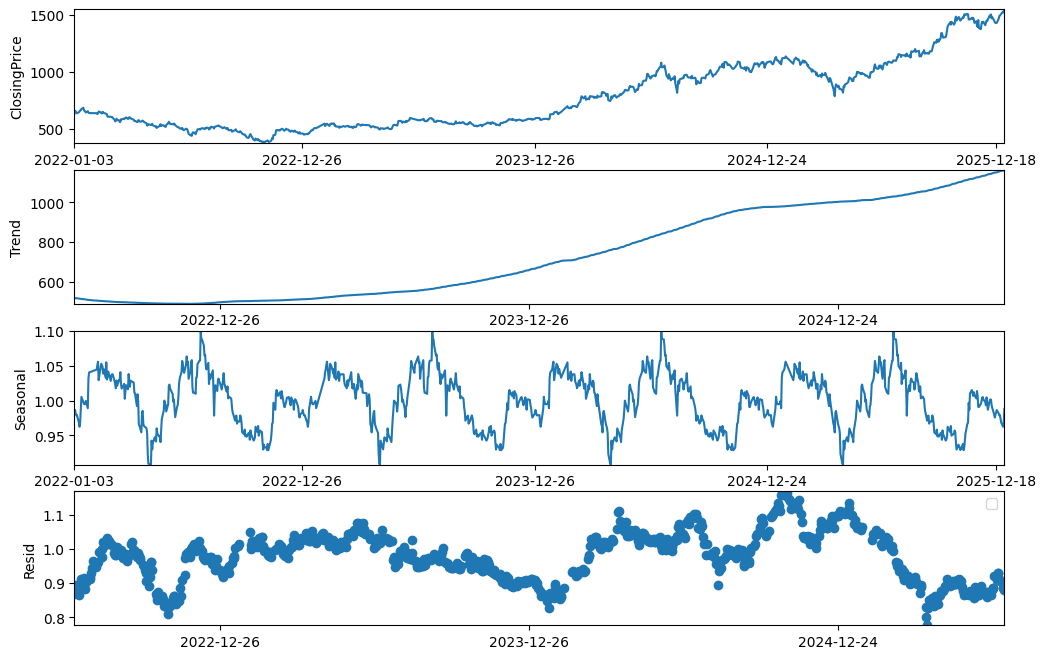

In [8]:
# 將 n 視為一年，也就是一個週期，是由 [一個月大約有 20 個交易日] * [12 個月]，所以 n = 20 * 12
n = 20 * 12     

 # 單純 x 軸 (2024/12/06) 刻度文字的旋轉角度  
ro= 0          

# seasonal_decompose 是一個已經實作好的函式，你把 arima_data、model='multiplicative'、period=n 這些參數傳進去後，它會依照內部實作進行時間序列分解，
# 最後回傳一個結果物件並指派給 result；而 result 擁有四個常用屬性：observed、trend、seasonal、resid。
# seasonal_decompose( 處理哪一份資料 , 要用哪一種模型 , 週期要設定多少) 的用途是將一條時間序列拆解成幾個部分
# 處理哪一份資料，也就是 arima_data，是 pandas Series 的資料結構，裡面包含了 index（日期）和 values（收盤價）
# 要用哪一種模型，原始時間序列是要「相加組成」還是「相乘組成」，additive、multiplicative，使用哪種取決於季節性的影響是固定增減量還是按比例放大或縮小
# period = n ，告訴模型我選擇一個完整的週期是 240 筆資料
result = seasonal_decompose(arima_data, model='multiplicative', period=n)


plt.figure(figsize=(12,8))  # 寬、高

# 第一張子圖
plt.subplot(4,1,1)                              # 將整張圖片切成 4 列，每一列只有 1 欄，然後選擇第一列的子圖來畫圖
plt.plot(result.observed, label="TSMC")
plt.ylabel("ClosingPrice")
plt.xticks(df.index[::n], rotation=ro)          # df.index[start : stop : step]，從頭開始一直到最後，每隔 n 筆資料取一個日期
plt.margins(0)

# 第二張子圖
# Tread 是由涵式將原始資料中短期上下震動弱化，只保留長期趨勢的變化，這樣就可以更清楚地看到資料的長期趨勢，而不會被短期的波動所干擾
plt.subplot(4,1,2)                              # 將整張圖片切成 4 列，每一列只有 1 欄，然後選擇第二列的子圖來畫圖
plt.plot(result.trend)
plt.ylabel("Trend")
plt.xticks(df.index[::n], rotation=ro)
plt.margins(0)

# 第三張子圖
# Seasonal 是函式根據 period=n，找出每一個週期裡重複出現的模式。觀察每隔 240 筆資料
plt.subplot(4,1,3)                             # 將整張圖片切成 4 列，每一列只有 1 欄，然後選擇第三列的子圖來畫圖
plt.plot(result.seasonal)
plt.ylabel("Seasonal")
plt.xticks(df.index[::n], rotation=ro)
plt.margins(0)

# 第四張子圖
# Resid 殘差，將原始資料扣掉或除掉趨勢或季節性後，剩下的部分就是無法被趨勢解釋和無法被季節性解釋的結果
plt.subplot(4,1,4)                             # 將整張圖片切成 4 列，每一列只有 1 欄，然後選擇第四列的子圖來畫圖
plt.scatter(df.index, result.resid)
plt.ylabel("Resid")
plt.xticks(df.index[::n], rotation=ro)
plt.margins(0)   # 拆成四個subplot以利調整圖片間距、x軸刻度的呈現

plt.legend()
plt.show()


In [9]:
# 這段程式是在做 ADF 檢定（Augmented Dickey-Fuller Test），用途是：判斷時間序列資料是否平穩（stationary）
# 因為很多時間序列模型，像是 ARIMA，通常都希望資料是平穩的，如果不平穩，就常要先做 差分（differencing）。

# 所謂的平穩，不是指數字完全不動，而是指這組資料平均值差不多固定，波動規律大致不變，不會一直往上飆或一直往下掉
# 為什麼要檢查平穩呢， 如果資料今天一種規律，明天又另一種規律，模型會很難抓到真正的規則，預測效果就會很差
# 所以透過 ADF 檢定知道這串資料到底穩不穩

#時間序列的資料再跑統計模型前，先做平穩性檢驗，來判斷資料是否平穩(stationary)
#如果不平穩，要做差分處理
#Dickey Fuller test是常用的檢定方式：
#如果檢驗統計量小於臨界值，我們可以拒絕原假設(也就是序列是平穩的)
#當檢驗統計量大於臨界值時，無法拒絕原假設(這意味著序列不是平穩的)


'''
 dftest = adfuller(timeseries, autolag="AIC")
 adfuller 是 ADF 檢定（Augmented Dickey-Fuller Test）的函式，用來檢查這筆 timeseries 資料是不是平穩序列
 autolag="AIC" 是讓程式自動幫你選擇最佳的 log 數量，log 太少模型可能不夠好，log 太多模型可能會太複雜，所以使用 AIC 在「模型複雜度」和「擬合效果」之間做平衡

 adffuller() 通常是一個 tuple 
 (
    test_statistic,   # 檢定統計量           dftest [0]
    p_value,          # p值                 dftest [1]
    used_lag,         # 實際用了幾個lag      dftest [2]     
    nobs,             # 使用了幾筆觀測值     dftest [3]
    critical_values,  # 臨界值              dftest [4] 是一個 dict，裡面有三個 key 分別是 "1%"、"5%"、"10%"，對應的 value 是在這些顯著水準下的臨界值
    icbest            # 最佳資訊準則值       dftest [5]
)
'''
def adf_test(timeseries):
    #Perform Dickey-Fuller test:
    print("Results of Dickey-Fuller Test\n==============================================")

    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(dftest[0:4], index = [
        "Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"]) 
    
    # dftest[4] 是臨界值
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" %key] = value
    print(dfoutput)
    print("==============================================")

    #寫個自動判斷式
    # ADF 預先的假設是不平穩的，所以當如果有足夠的證據拒絕原假設，就代表該資料在 Criterical Value 1% 下是平穩的；反之，如果無法拒絕原假設，就代表資料不是平穩的，那就必須做差分處理
    if dfoutput[0] < dfoutput[4]:
        print("The data is stationary. (Criterical Value 1%)")
    elif dfoutput[0] < dfoutput[5]:
        print("The data is stationary. (Criterical Value 5%)")
    elif dfoutput[0] < dfoutput[6]:
        print("The data is stationary. (Criterical Value 10%)")
    else:
        print("The data is non-stationary, so do differencing!  所以要做差分處理 ! ")

adf_test(arima_data)

Results of Dickey-Fuller Test
Test Statistic                   1.301789
p-value                          0.996619
#Lags Used                       9.000000
Number of Observations Used    959.000000
Critical Value (1%)             -3.437187
Critical Value (5%)             -2.864559
Critical Value (10%)            -2.568377
dtype: float64
The data is non-stationary, so do differencing!  所以要做差分處理 ! 


In [ ]:
arima_data.plot(figsize=(12,8), label="original")
plt.legend()
plt.show()

Date
2022-01-04    25.0
2022-01-05    -6.0
2022-01-06    -6.0
2022-01-07   -10.0
2022-01-10     9.0
Name: ClosingPrice, dtype: float64
Results of Dickey-Fuller Test
Test Statistic                -9.227074e+00
p-value                        1.717691e-15
#Lags Used                     8.000000e+00
Number of Observations Used    9.590000e+02
Critical Value (1%)           -3.437187e+00
Critical Value (5%)           -2.864559e+00
Critical Value (10%)          -2.568377e+00
dtype: float64
The data is stationary. (Criterical Value 1%)


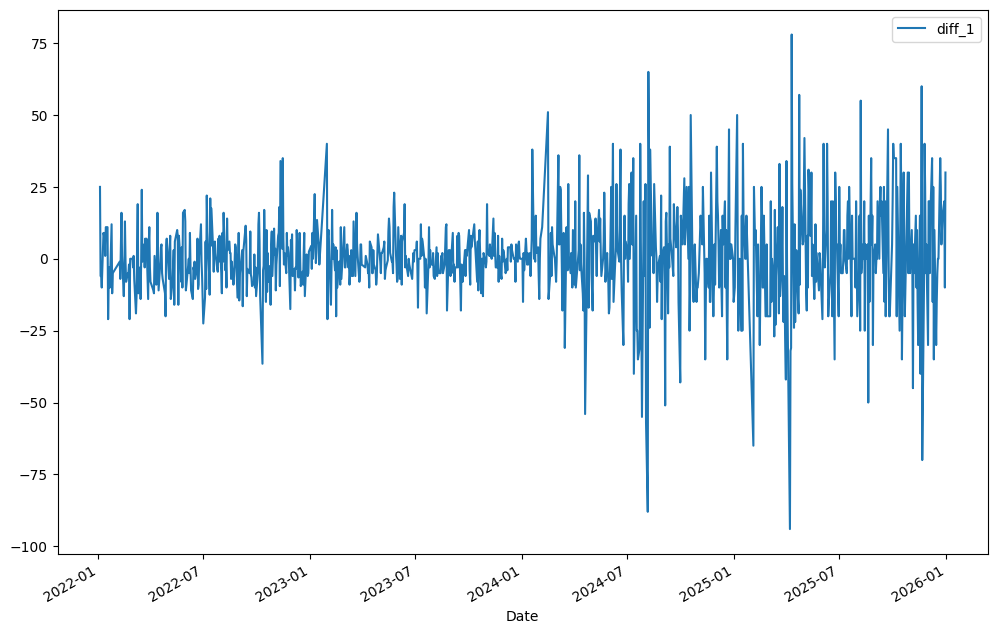

In [ ]:
# diff_1 是做第一次的差分。今天的值 - 前一天的值
"""
arima_data.shift(1)  也就是把整個時間序列往下移一格

(日期 , 收盤價)                     (日期 , shift(1))               
(1/1 , 100)                           (1/1 , NaN)                   
(1/2 , 105)      shift (1) 之後       (1/2 , 100)       差分之後      diff [NaN , 5 ,3]
(1/3 , 108)                          (1/3 , 105)
"""

diff_1 = arima_data - arima_data.shift(1)
# 因為第一筆資料是 Nan 沒有前一筆資料可以做相減所以要將它個空值刪除，使用 dropna()
diff_1 = diff_1.dropna()                        
print(diff_1.head())


diff_1.plot(figsize=(12,8), label="diff_1")
plt.legend()        # 標籤

adf_test(diff_1)

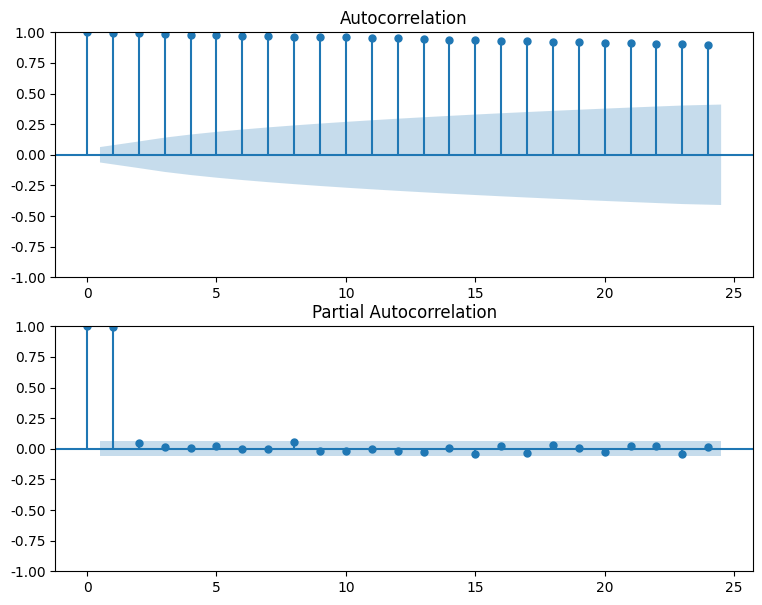

c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A

ARIMA(0,1,0) : AIC=8130.7388478016965
ARIMA(0,1,1) : AIC=8127.230737622245
ARIMA(0,1,2) : AIC=8124.460250573758
ARIMA(1,1,0) : AIC=8128.03121425895
ARIMA(1,1,1) : AIC=8126.744327005332
ARIMA(1,1,2) : AIC=8125.362892815747
ARIMA(2,1,0) : AIC=8124.2486305104585
ARIMA(2,1,1) : AIC=8125.16412631462


c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A

ARIMA(2,1,2) : AIC=8115.045590396628
ARIMA(3,1,0) : AIC=8125.727471864106


c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A

ARIMA(3,1,1) : AIC=8127.152771303933


c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(3,1,2) : AIC=8114.120895602661
This best model is ARIMA(3,1,2) based on argmin AIC.


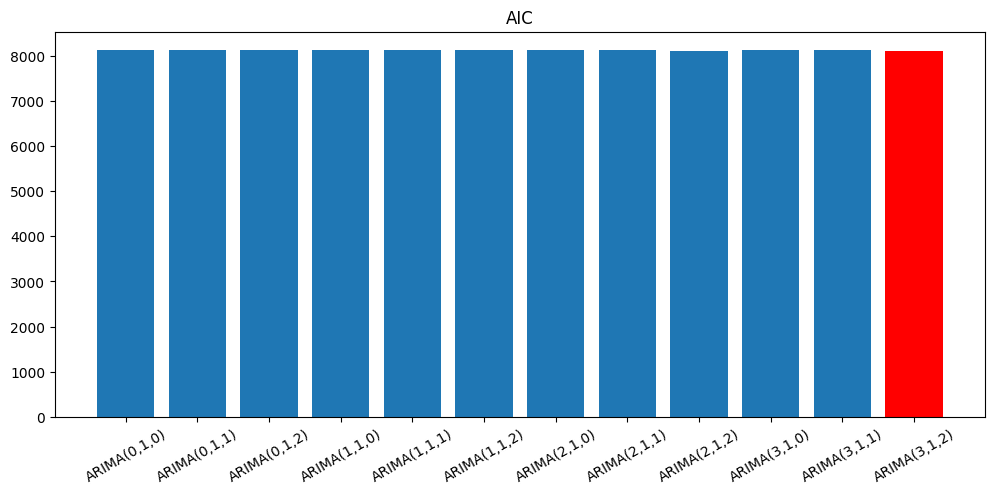

c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\YangYUCheng\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A

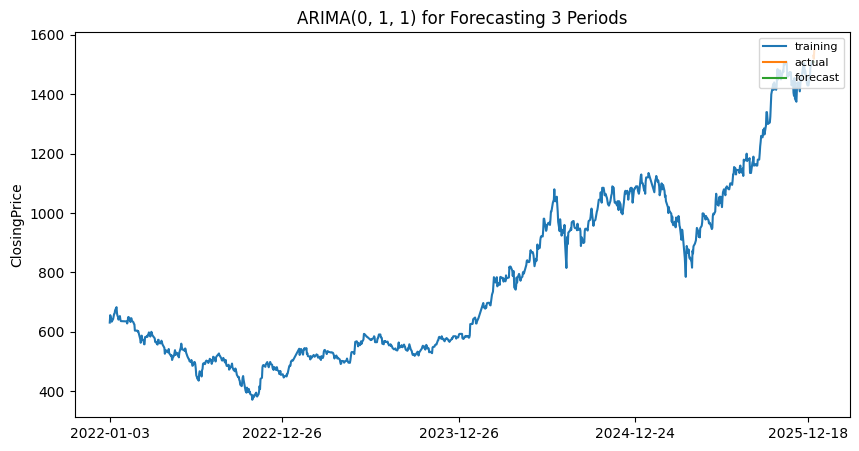

Mean Absolute Error : 24.601113400335937
Mean Squared Error : 760.770336091744
fc_series: Date
2025-12-29    1508.73222
2025-12-30    1508.73222
2025-12-31    1508.73222
dtype: float64
ClosingPrice Date
2025-12-29    1530.0
2025-12-30    1520.0
2025-12-31    1550.0
Name: ClosingPrice, dtype: float64


In [11]:
#畫ACF(Autocorrelation Function)、PACF(Partial Autocorrelation Function)圖
#可幫助我們判斷模型ARIMA(p, d, q)參數的選擇
#correlogram

f = plt.figure(facecolor='white', figsize=(9,7))
ax1 = f.add_subplot(211)
plot_acf(arima_data, lags=24, ax=ax1)
ax2 = f.add_subplot(212)
plot_pacf(arima_data, lags=24, ax=ax2)
plt.rcParams['axes.unicode_minus'] = False
plt.show()

#5. 樣本內預測模型建立
#在這個部分，我們選擇用透過尋找最小AIC方式來選擇p,d,q的值
def arima_AIC(data, p=4, d=3, q=4):
    best_AIC = ["pdq",10000]
    #L = len(data)
    AIC = []
    name = []
    for i in range(p):
        for j in range(1,d):
            for k in range(q):
                model = ARIMA(data, order=(i,j,k))
                #fitted = model.fit(disp=-1)
                fitted = model.fit()
                AIC.append(fitted.aic)
                name.append(f"ARIMA({i},{j},{k})")
                print(f"ARIMA({i},{j},{k}) : AIC={fitted.aic}")
                if fitted.aic < best_AIC[1]:
                    best_AIC[0] = f"ARIMA({i},{j},{k})"
                    best_AIC[1] = fitted.aic

    print("==============================================================")
    print(f"This best model is {best_AIC[0]} based on argmin AIC.")
    plt.figure(figsize=(12,5))
    plt.bar(name, AIC)
    plt.bar(best_AIC[0], best_AIC[1], color = "red")
    plt.xticks(rotation=30)
    plt.title("AIC")
    plt.savefig("Arima AIC")
    plt.show()

arima_AIC(arima_data, 4,2,3)

#ARIMA(0,1,1) : AIC=8037.9170939612
model = ARIMA(arima_data, order=(0, 1, 1))  #修改 p,d,q參數

#data split
period = 3  #預測 後續 週期
title = f'ARIMA(0, 1, 1) for Forecasting {period} Periods'
L = len(arima_data)
x_train = arima_data[:(L-period)]
x_test = arima_data[-period:]

#Build Model
model = ARIMA(x_train, order=(0, 1, 1))
#fitted = model.fit(disp=-1)
fitted = model.fit()

#Forecast
fc, se, conf = fitted.forecast(period, alpha=0.05)  # 95% conf
#Make as pandas series
fc_series = pd.Series(fc, index=x_test.index)

#Plot
plt.figure(figsize=(10,5), dpi=100)
plt.plot(x_train, label='training')
plt.plot(x_test, label='actual')
plt.plot(fc_series, label='forecast')
plt.xticks(df.index[::n], rotation=ro)  #plt.xticks(df.index[::12], rotation=90)
plt.title(title)
plt.ylabel("ClosingPrice")
plt.legend(loc='upper right', fontsize=8)
plt.savefig(title)
plt.show()

#Results
print(f'Mean Absolute Error : {mean_absolute_error(fc_series,x_test)}')
print(f'Mean Squared Error : {mean_squared_error(fc_series,x_test)}')
print('==============================')
print('fc_series:', fc_series)
print('==============================')
print('ClosingPrice', x_test)